# Bridge Author Work Popularity vs. Fandom Size Analysis

This notebook explores the popularity of works written by **bridge authors** (authors who write for multiple distinct fandoms) compared to the average/median popularity within those fandoms. Specifically, we calculate the ratio of a work's popularity (e.g., Hits, Kudos, or Comments) to the average and median metrics of all works in its fandom. We then analyze whether bridge authors achieve relatively higher popularity in smaller fandoms compared to larger ones.

## 1. Setup, Imports, and Data Loading

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

from ao3_loader import AO3DatasetLoader
from ao3_manipulator import AO3DataManipulator
from ao3_clustering import AO3FandomClustering

# Initialize loader and load the preprocessed dataframe
loader = AO3DatasetLoader()
df = loader.get_preprocessed_dataframe()

File already exists at: random works - Oct 2025.csv. Skipping download.
Loading dataset from random works - Oct 2025.csv...


Parsing list columns (Authors, Fandom Tags, Freeform Tags)...


Preprocessing complete.


## 2. Data Cleaning and Manipulation

In [2]:
# Clean and manipulate the dataset upstream using the AO3DataManipulator
manipulator = AO3DataManipulator(df)
manipulated_df = manipulator.run_all_manipulations()

print(f"Clean manipulated dataset size: {len(manipulated_df):,} rows.")

Clean manipulated dataset size: 76,886 rows.


## 3. Playable Parameter Selection

Modify the parameters in the cell below to experiment with different popularity metrics and fandom definitions.

In [3]:
# =====================================================================
# PLAYABLE PARAMETERS
# =====================================================================

# 1. Choose your popularity metric: 'Hits', 'Kudos', or 'Comments'
TARGET_METRIC = 'Hits'

# 2. Choose how you define the primary fandom tag:
#    - 'fandom_tag_1'   : The first fandom tag listed on the work.
#    - 'fandom_cluster' : Fandom tags consolidated into connected-component clusters (threshold=0.5).
#    - 'clustered_fandom': Fandom tags consolidated into high-threshold overlap clusters (threshold=0.7).
FANDOM_COLUMN = 'fandom_tag_1'

# 3. Set a minimum fandom size (number of works) to filter out tiny fandoms from the analysis
MIN_FANDOM_SIZE = 10

print(f"Selected metric: {TARGET_METRIC}")
print(f"Selected fandom column representation: {FANDOM_COLUMN}")
print(f"Selected minimum fandom size: {MIN_FANDOM_SIZE}")

Selected metric: Hits
Selected fandom column representation: fandom_tag_1
Selected minimum fandom size: 10


## 4. Compute Fandom Group Statistics

In [4]:
# Map clustered columns if requested
working_df = manipulated_df.copy()

if FANDOM_COLUMN == 'fandom_cluster':
    print("Consolidating fandom tags into connected-component clusters (threshold=0.5)...")
    clustering = AO3FandomClustering(working_df, threshold=0.5)
    working_df = clustering.get_clustered_dataframe()
elif FANDOM_COLUMN == 'clustered_fandom':
    print("Consolidating fandom tags into high-threshold overlap clusters (threshold=0.7)...")
    clustering = AO3FandomClustering(working_df, threshold=0.5)
    clustering.create_clusters()
    working_df = clustering.get_clustered_fandom_dataframe(threshold=0.7)

# Compute fandom size, mean, and median popularity
fandom_stats = working_df.groupby(FANDOM_COLUMN).agg(
    fandom_size=('Title', 'count'),
    fandom_mean_val=(TARGET_METRIC, 'mean'),
    fandom_median_val=(TARGET_METRIC, 'median')
).reset_index()

print(f"Computed statistics for {len(fandom_stats)} fandoms using metric: {TARGET_METRIC}.")
fandom_stats.head(10)

Computed statistics for 1424 fandoms using metric: Hits.


,fandom_tag_1,fandom_size,fandom_mean_val,fandom_median_val
0,&TEAM (Band),32,1505.718750,821.0
1,(여자)아이들 | (G)I-DLE,20,861.500000,540.5
2,101 Dalmatian Street (Cartoon),16,2878.437500,459.0
3,1776 (1972),8,555.250000,383.0
4,19th Century CE RPF,5,907.600000,147.0
5,20th Century CE RPF,7,399.571429,180.0
6,3rd Life | Last Life SMP Series,199,1053.427136,596.0
7,5 Seconds of Summer (Band),56,1004.535714,687.5
8,9-1-1 (TV),206,5011.029126,2411.5
9,9-1-1: Lone Star (TV 2020),36,3895.527778,2248.0


## 5. Identify Bridge Authors & Calculate Popularity Ratios

In [5]:
# Merge statistics back into the working dataframe
merged_df = pd.merge(working_df, fandom_stats, on=FANDOM_COLUMN, how='left')

# Ensure author is extracted as a string for grouping
merged_df['author_str'] = merged_df['parsed_authors'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')
merged_df = merged_df[merged_df['author_str'] != 'Unknown']

# Find bridge authors: authors who have written in 2 or more distinct fandom entities
author_fandom_counts = merged_df.groupby('author_str')[FANDOM_COLUMN].nunique()
bridge_authors_list = author_fandom_counts[author_fandom_counts >= 2].index.tolist()

print(f"Found {len(bridge_authors_list):,} bridge authors writing in 2 or more distinct fandom entities.")

# Filter to works written by bridge authors
bridge_works = merged_df[merged_df['author_str'].isin(bridge_authors_list)].copy()

# Calculate popularity ratio: work popularity compared to fandom average and median
bridge_works['ratio_vs_mean'] = bridge_works[TARGET_METRIC] / bridge_works['fandom_mean_val']
bridge_works['ratio_vs_median'] = bridge_works[TARGET_METRIC] / bridge_works['fandom_median_val']

# Handle division by zero or NaN values
bridge_works = bridge_works.replace([np.inf, -np.inf], np.nan).dropna(subset=['ratio_vs_mean', 'ratio_vs_median'])

# Filter out tiny fandoms based on our selection
bridge_works_filtered = bridge_works[bridge_works['fandom_size'] >= MIN_FANDOM_SIZE]

print(f"Total works by bridge authors in fandoms with size >= {MIN_FANDOM_SIZE}: {len(bridge_works_filtered):,}")

Found 4,197 bridge authors writing in 2 or more distinct fandom entities.
Total works by bridge authors in fandoms with size >= 10: 13,633


## 6. Correlation Analysis & Visualizations

We plot the bridge author's popularity ratio against the fandom size (on a log scale) and compute the Spearman rank correlation coefficient. A negative correlation indicates that bridge authors achieve relatively higher popularity (higher ratios relative to the fandom baseline) in smaller fandoms.

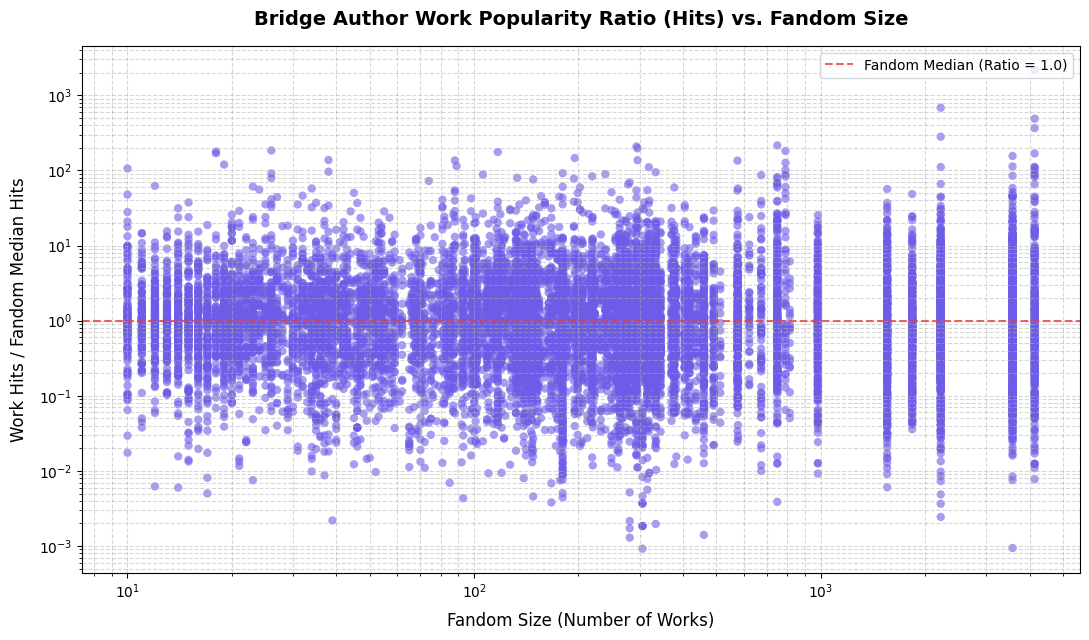

CORRELATION ANALYSIS SUMMARY (Metric: Hits, Fandom Col: fandom_tag_1)
Spearman rank correlation: -0.0211
p-value: 1.3911e-02
------------------------------------------------------------
Result: Statistically significant NEGATIVE correlation (-0.0211).
This supports the hypothesis: bridge authors achieve relatively higher popularity (Hits) in smaller fandoms.


In [6]:
# 1. Plot Popularity Ratio vs Fandom Size
plt.figure(figsize=(11, 6.5))

sns.scatterplot(
    data=bridge_works_filtered, 
    x='fandom_size', 
    y='ratio_vs_median', 
    alpha=0.6, 
    color='#6c5ce7', 
    edgecolor='none'
)

plt.xscale('log')
plt.yscale('log')

plt.axhline(1.0, color='#e53e3e', linestyle='--', linewidth=1.5, alpha=0.8, label='Fandom Median (Ratio = 1.0)')
plt.xlabel('Fandom Size (Number of Works)', fontsize=12, labelpad=8)
plt.ylabel(f'Work {TARGET_METRIC} / Fandom Median {TARGET_METRIC}', fontsize=12, labelpad=8)
plt.title(f'Bridge Author Work Popularity Ratio ({TARGET_METRIC}) vs. Fandom Size', fontsize=14, weight='bold', pad=15)
plt.legend(loc='upper right')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig('docs/popularity_vs_fandom_size.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Compute Spearman Rank Correlation (non-linear, robust to outliers)
corr_coeff, p_value = spearmanr(bridge_works_filtered['fandom_size'], bridge_works_filtered['ratio_vs_median'])

print("=" * 60)
print(f"CORRELATION ANALYSIS SUMMARY (Metric: {TARGET_METRIC}, Fandom Col: {FANDOM_COLUMN})")
print("=" * 60)
print(f"Spearman rank correlation: {corr_coeff:.4f}")
print(f"p-value: {p_value:.4e}")
print("-" * 60)

if corr_coeff < 0 and p_value < 0.05:
    print(f"Result: Statistically significant NEGATIVE correlation ({corr_coeff:.4f}).")
    print(f"This supports the hypothesis: bridge authors achieve relatively higher popularity ({TARGET_METRIC}) in smaller fandoms.")
elif corr_coeff < 0:
    print(f"Result: Weak negative correlation ({corr_coeff:.4f}), but not statistically significant (p = {p_value:.3f}).")
else:
    print(f"Result: No negative correlation found ({corr_coeff:.4f}).")
    print("Bridge authors do not achieve relatively higher popularity in smaller fandoms.")
print("=" * 60)

## 7. Deep Dive: Marvel (Mega-Fandom) vs. Teen Wolf (Small Fandom) Crossover

In this section, we perform a deep-dive analysis on the bridge authors who write for both the **Marvel Fandom** (a mega-fandom) and the **Teen Wolf Fandom** (a relatively small fandom).

As noted during fandom clustering, connected-component clustering at a 0.5 threshold groups `'Teen Wolf (TV)'` under the `'Marvel Cinematic Universe'` cluster due to structural crossover chaining. To ensure absolute precision and keep the two fandoms separate, we filter works using case-insensitive string matching directly on the raw `'Fandom Tags'` column.

Specifically, we:
1. Filter works matching `marvel|avengers|mcu` for Marvel, and `teen wolf` for Teen Wolf.
2. Identify the unique bridge authors writing in both groups.
3. Extract all works by these bridge authors in both fandoms into a combined, clean DataFrame (`marvel_tw_bridge_df`) and export it to a CSV file.
4. Calculate overall fandom baselines and compare them to the bridge authors' works using the active `TARGET_METRIC` (e.g., Hits, Kudos, or Comments).

Saved filtered bridge works to 'marvel_tw_bridge_works.csv'.
DEEP DIVE: MARVEL VS. TEEN WOLF (Metric: Hits)
Number of true bridge authors identified: 9
Marvel bridge works: 12 works
Teen Wolf bridge works: 10 works
Total bridge works in combined DataFrame: 22
------------------------------------------------------------
Marvel Fandom Overall Median Hits: 1123.0 (Mean: 4354.0)
Bridge Authors' Marvel Works Median Hits: 1896.0 (Mean: 5216.1)
Relative Popularity Ratio in Marvel: 1.6883
------------------------------------------------------------
Teen Wolf Fandom Overall Median Hits: 2229.0 (Mean: 5354.8)
Bridge Authors' Teen Wolf Works Median Hits: 2300.0 (Mean: 7478.0)
Relative Popularity Ratio in Teen Wolf: 1.0319

Preview of Marvel vs. Teen Wolf Bridge Works:
                                                Title  \
0                      Prince Charming and His Knight   
1                                 I’ll Watch Over You   
2   That American Dream (it'll get you every time ...   
3   

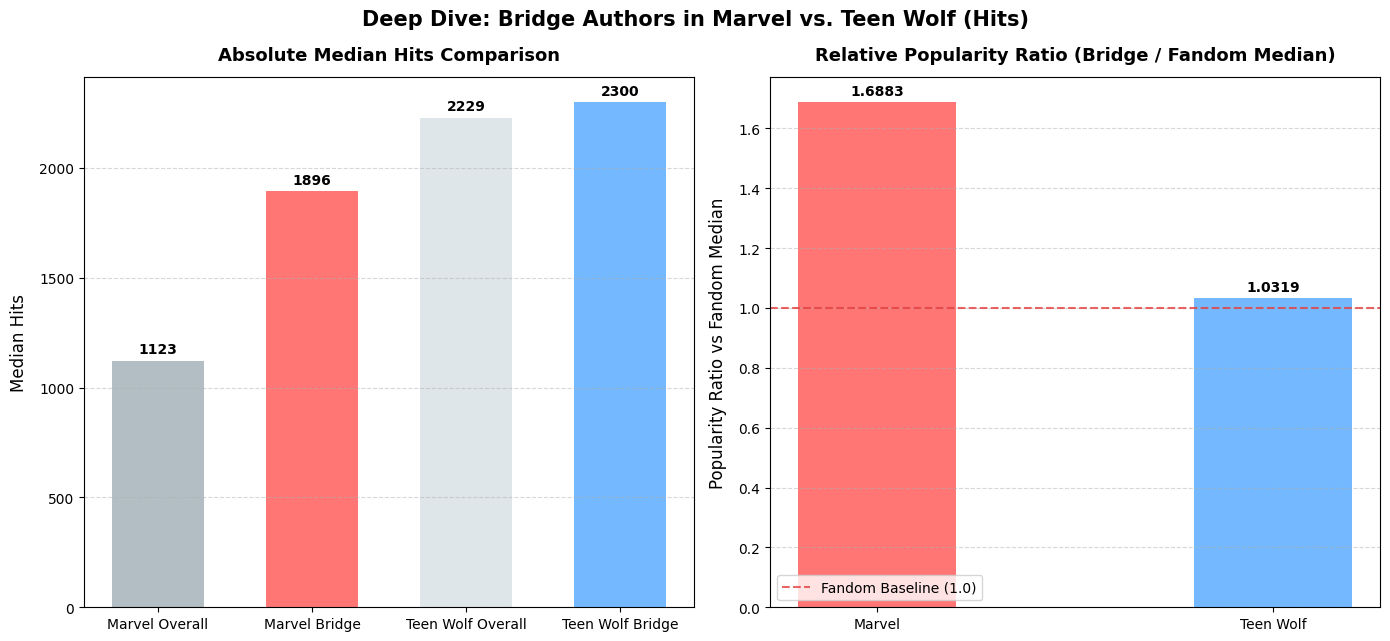

In [7]:
import re
import pandas as pd

# Ensure author_str exists in manipulated_df
if 'author_str' not in manipulated_df.columns:
    manipulated_df['author_str'] = manipulated_df['parsed_authors'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')

# 1. Define case-insensitive regex patterns for the two target fandoms
marvel_pat = re.compile(r'marvel|avengers|mcu', re.IGNORECASE)
teen_wolf_pat = re.compile(r'teen wolf', re.IGNORECASE)

# 2. Filter the manipulated DataFrame using string masks on raw 'Fandom Tags'
is_marvel = manipulated_df['Fandom Tags'].apply(lambda x: bool(marvel_pat.search(str(x))))
is_teen_wolf = manipulated_df['Fandom Tags'].apply(lambda x: bool(teen_wolf_pat.search(str(x))))

# 3. Exclude crossover works (works tagged with both Marvel AND Teen Wolf)
is_crossover = is_marvel & is_teen_wolf
marvel_only_df = manipulated_df[is_marvel & ~is_crossover].copy()
teen_wolf_only_df = manipulated_df[is_teen_wolf & ~is_crossover].copy()

# 4. Identify unique bridge authors writing in both fandoms (excluding crossovers)
marvel_only_authors = set(marvel_only_df['author_str'].unique())
teen_wolf_only_authors = set(teen_wolf_only_df['author_str'].unique())
bridge_authors = marvel_only_authors.intersection(teen_wolf_only_authors)
if 'Unknown' in bridge_authors:
    bridge_authors.remove('Unknown')

# 5. Filter works by bridge authors in both fandoms (excluding crossovers)
marvel_bridge = marvel_only_df[marvel_only_df['author_str'].isin(bridge_authors)].copy()
teen_wolf_bridge = teen_wolf_only_df[teen_wolf_only_df['author_str'].isin(bridge_authors)].copy()

# 6. Create a combined filtered DataFrame containing only the works of these bridge authors in Marvel and Teen Wolf
marvel_bridge['fandom_group'] = 'Marvel'
teen_wolf_bridge['fandom_group'] = 'Teen Wolf'
marvel_tw_bridge_df = pd.concat([marvel_bridge, teen_wolf_bridge], ignore_index=True)

# Save to CSV for easy export and further deep-dive analysis
marvel_tw_bridge_df.to_csv('marvel_tw_bridge_works.csv', index=False)
print("Saved filtered bridge works to 'marvel_tw_bridge_works.csv'.")

# 7. Calculate overall baselines for TARGET_METRIC (using all Marvel/Teen Wolf works)
marvel_overall_mean = manipulated_df[is_marvel][TARGET_METRIC].mean()
marvel_overall_median = manipulated_df[is_marvel][TARGET_METRIC].median()

tw_overall_mean = manipulated_df[is_teen_wolf][TARGET_METRIC].mean()
tw_overall_median = manipulated_df[is_teen_wolf][TARGET_METRIC].median()

# 8. Calculate bridge author work statistics for TARGET_METRIC (using non-crossover bridge works)
marvel_bridge_mean = marvel_bridge[TARGET_METRIC].mean()
marvel_bridge_median = marvel_bridge[TARGET_METRIC].median()
marvel_bridge_ratio = marvel_bridge_median / marvel_overall_median if marvel_overall_median > 0 else 0

tw_bridge_mean = teen_wolf_bridge[TARGET_METRIC].mean()
tw_bridge_median = teen_wolf_bridge[TARGET_METRIC].median()
tw_bridge_ratio = tw_bridge_median / tw_overall_median if tw_overall_median > 0 else 0

# 9. Print summary statistics
print("=" * 60)
print(f"DEEP DIVE: MARVEL VS. TEEN WOLF (Metric: {TARGET_METRIC})")
print("=" * 60)
print(f"Number of true bridge authors identified: {len(bridge_authors)}")
print(f"Marvel bridge works: {len(marvel_bridge)} works")
print(f"Teen Wolf bridge works: {len(teen_wolf_bridge)} works")
print(f"Total bridge works in combined DataFrame: {len(marvel_tw_bridge_df)}")
print("-" * 60)
print(f"Marvel Fandom Overall Median {TARGET_METRIC}: {marvel_overall_median:.1f} (Mean: {marvel_overall_mean:.1f})")
print(f"Bridge Authors' Marvel Works Median {TARGET_METRIC}: {marvel_bridge_median:.1f} (Mean: {marvel_bridge_mean:.1f})")
print(f"Relative Popularity Ratio in Marvel: {marvel_bridge_ratio:.4f}")
print("-" * 60)
print(f"Teen Wolf Fandom Overall Median {TARGET_METRIC}: {tw_overall_median:.1f} (Mean: {tw_overall_mean:.1f})")
print(f"Bridge Authors' Teen Wolf Works Median {TARGET_METRIC}: {tw_bridge_median:.1f} (Mean: {tw_bridge_mean:.1f})")
print(f"Relative Popularity Ratio in Teen Wolf: {tw_bridge_ratio:.4f}")
print("=" * 60)

# 10. Show a preview of the bridge works
print("\nPreview of Marvel vs. Teen Wolf Bridge Works:")
print(marvel_tw_bridge_df[['Title', 'author_str', 'fandom_group', TARGET_METRIC, 'Words']].head(15))

# 11. Render a premium comparison visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

# Subplot 1: Absolute Medians comparison
categories = ['Marvel Overall', "Marvel Bridge", 'Teen Wolf Overall', "Teen Wolf Bridge"]
values = [marvel_overall_median, marvel_bridge_median, tw_overall_median, tw_bridge_median]
colors = ['#b2bec3', '#ff7675', '#dfe6e9', '#74b9ff']

bars1 = ax1.bar(categories, values, color=colors, edgecolor='none', width=0.6)
ax1.set_ylabel(f'Median {TARGET_METRIC}', fontsize=12, labelpad=8)
ax1.set_title(f'Absolute Median {TARGET_METRIC} Comparison', fontsize=13, weight='bold', pad=12)
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)

# Add value labels on top of the bars
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:.0f}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),  # 3 points vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=10, weight='bold')

# Subplot 2: Relative Popularity Ratio comparison
ratios = [marvel_bridge_ratio, tw_bridge_ratio]
ratio_labels = ['Marvel', 'Teen Wolf']
ratio_colors = ['#ff7675', '#74b9ff']

bars2 = ax2.bar(ratio_labels, ratios, color=ratio_colors, edgecolor='none', width=0.4)
ax2.axhline(1.0, color='#e53e3e', linestyle='--', linewidth=1.5, alpha=0.8, label='Fandom Baseline (1.0)')
ax2.set_ylabel(f'Popularity Ratio vs Fandom Median', fontsize=12, labelpad=8)
ax2.set_title(f'Relative Popularity Ratio (Bridge / Fandom Median)', fontsize=13, weight='bold', pad=12)
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)
ax2.legend(loc='lower left')

# Add ratio labels on top of the bars
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{height:.4f}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),  # 3 points vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=10, weight='bold')

plt.suptitle(f'Deep Dive: Bridge Authors in Marvel vs. Teen Wolf ({TARGET_METRIC})', fontsize=15, weight='bold', y=0.98)
plt.tight_layout()
plt.savefig('docs/marvel_teen_wolf_deep_dive.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Hit / Kudos / Comment Distributions by Fandom Size (All Works)

We segment fandoms into **Small** (< 50 works), **Medium** (50–500 works) and **Large** (> 500 works) based on the number of works under each primary fandom tag. We then plot the **distribution of Hits, Kudos, and Comments** for each size group using violin + box plots to expose skew.

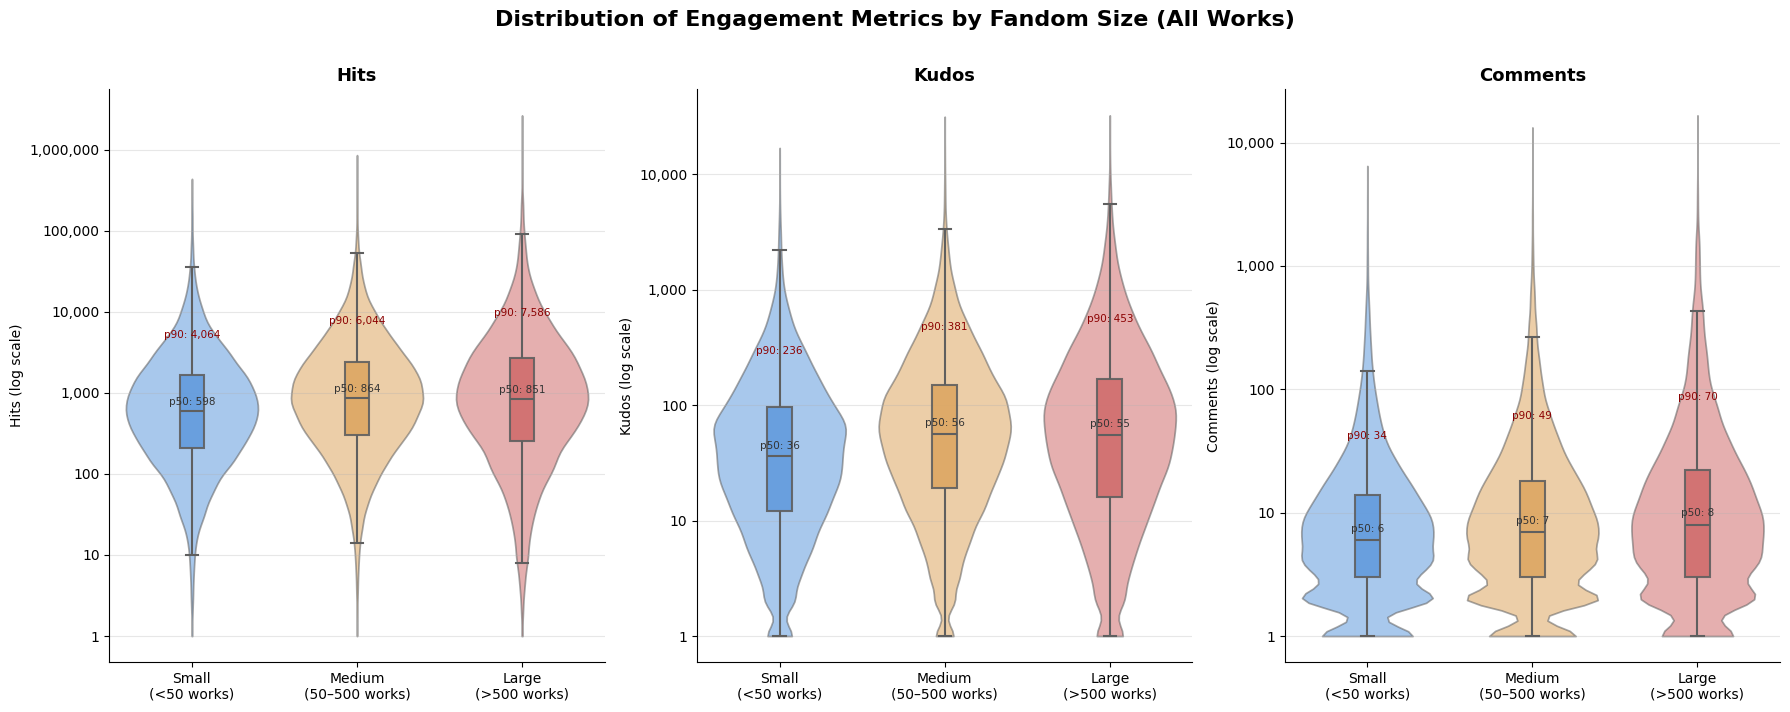

Saved: docs/fandom_size_distributions_all.png

=== Percentile Summary (All Works) ===
          Fandom Size   Metric     N  p10  p50  p90   p99
    Small (<50 works)     Hits 19240   75  598 4064 23355
    Small (<50 works)    Kudos 19240    4   36  236  1099
    Small (<50 works) Comments 19240    1    6   34   280
Medium (50–500 works)     Hits 38031  108  864 6044 33956
Medium (50–500 works)    Kudos 38031    6   56  381  1932
Medium (50–500 works) Comments 38031    2    7   49   401
   Large (>500 works)     Hits 19615   71  851 7586 58728
   Large (>500 works)    Kudos 19615    5   55  453  2634
   Large (>500 works) Comments 19615    2    8   70   751


In [8]:
# ── 8. Hit / Kudos / Comment Distributions by Fandom Size ──────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd

# ── Fandom size segmentation ─────────────────────────────────────────────
work_df = manipulated_df.copy()

# Primary fandom tag already computed as fandom_tag_1
fandom_counts = work_df['fandom_tag_1'].value_counts()

def fandom_size_label(count):
    if count < 50:
        return 'Small\n(<50 works)'
    elif count <= 500:
        return 'Medium\n(50–500 works)'
    else:
        return 'Large\n(>500 works)'

work_df['fandom_size'] = work_df['fandom_tag_1'].map(fandom_counts).apply(fandom_size_label)

size_order = ['Small\n(<50 works)', 'Medium\n(50–500 works)', 'Large\n(>500 works)']
size_palette = {'Small\n(<50 works)': '#4E9AF1',
                'Medium\n(50–500 works)': '#F1A94E',
                'Large\n(>500 works)': '#E05C5C'}

metrics = ['Hits', 'Kudos', 'Comments']
metric_labels = {'Hits': 'Hits (log scale)',
                 'Kudos': 'Kudos (log scale)',
                 'Comments': 'Comments (log scale)'}

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=False)
fig.suptitle('Distribution of Engagement Metrics by Fandom Size (All Works)',
             fontsize=16, fontweight='bold', y=1.01)

for ax, metric in zip(axes, metrics):
    plot_data = work_df[['fandom_size', metric]].dropna()
    plot_data = plot_data[plot_data[metric] > 0].copy()
    plot_data['log_metric'] = np.log10(plot_data[metric])

    sns.violinplot(data=plot_data, x='fandom_size', y='log_metric',
                   order=size_order, palette=size_palette,
                   inner=None, cut=0, alpha=0.55, ax=ax)
    sns.boxplot(data=plot_data, x='fandom_size', y='log_metric',
                order=size_order, palette=size_palette,
                width=0.15, fliersize=0, linewidth=1.5,
                boxprops=dict(alpha=0.9), ax=ax)

    # Annotate p50 and p90
    for i, sz in enumerate(size_order):
        vals = plot_data.loc[plot_data['fandom_size'] == sz, metric]
        if len(vals) == 0:
            continue
        p50 = np.percentile(vals, 50)
        p90 = np.percentile(vals, 90)
        ax.text(i, np.log10(p50) + 0.05, f'p50: {int(p50):,}',
                ha='center', va='bottom', fontsize=7.5, color='#333')
        ax.text(i, np.log10(p90) + 0.05, f'p90: {int(p90):,}',
                ha='center', va='bottom', fontsize=7.5, color='#8B0000')

    ax.set_title(metric, fontsize=13, fontweight='semibold')
    ax.set_xlabel('')
    ax.set_ylabel(metric_labels[metric], fontsize=10)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f'{10**v:,.0f}'))
    ax.grid(axis='y', alpha=0.3)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('docs/fandom_size_distributions_all.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved: docs/fandom_size_distributions_all.png')

# ── Print summary stats table ─────────────────────────────────────────────
print('\n=== Percentile Summary (All Works) ===')
rows = []
for sz in size_order:
    grp = work_df[work_df['fandom_size'] == sz]
    n = len(grp)
    for m in metrics:
        vals = grp[m].dropna()
        vals = vals[vals > 0]
        rows.append({
            'Fandom Size': sz.replace('\n', ' '),
            'Metric': m,
            'N': n,
            'p10': int(np.percentile(vals, 10)) if len(vals) else None,
            'p50': int(np.percentile(vals, 50)) if len(vals) else None,
            'p90': int(np.percentile(vals, 90)) if len(vals) else None,
            'p99': int(np.percentile(vals, 99)) if len(vals) else None,
        })
summary_all = pd.DataFrame(rows)
print(summary_all.to_string(index=False))


## 9. Bridge Author Engagement & Content Profile by Fandom Size

We repeat the distribution analysis **restricted to bridge authors** (authors who have at least one work in two or more distinct fandoms, excluding crossover works). We additionally compute:
- **% Mature/Explicit** ratings
- **% Works with Archive Warnings** (i.e., not 'No Archive Warnings Apply' and not 'Creator Chose Not To Use Archive Warnings')

Bridge authors identified: 1,458
Bridge author works: 5,957
fandom_size
Medium\n(50–500 works)    2934
Small\n(<50 works)        1847
Large\n(>500 works)       1176
Name: count, dtype: int64


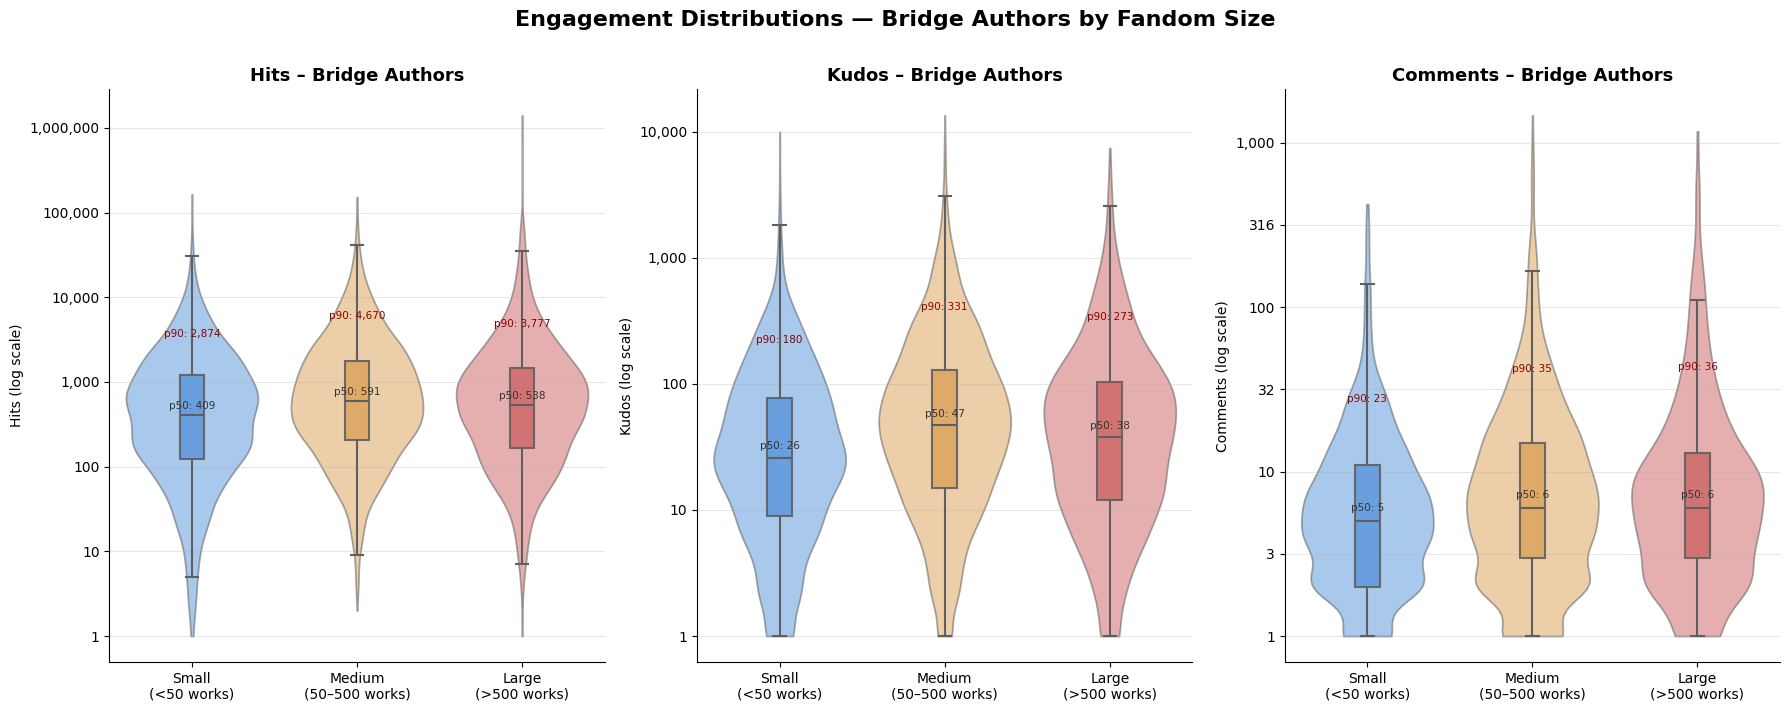

Saved: docs/fandom_size_distributions_bridge.png

=== Content Profile — Bridge Authors by Fandom Size ===
          Fandom Size  N works  % Mature/Explicit  % With Archive Warning
    Small (<50 works)     1847               30.7                    11.0
Medium (50–500 works)     2934               26.5                    10.3
   Large (>500 works)     1176               26.4                    12.1


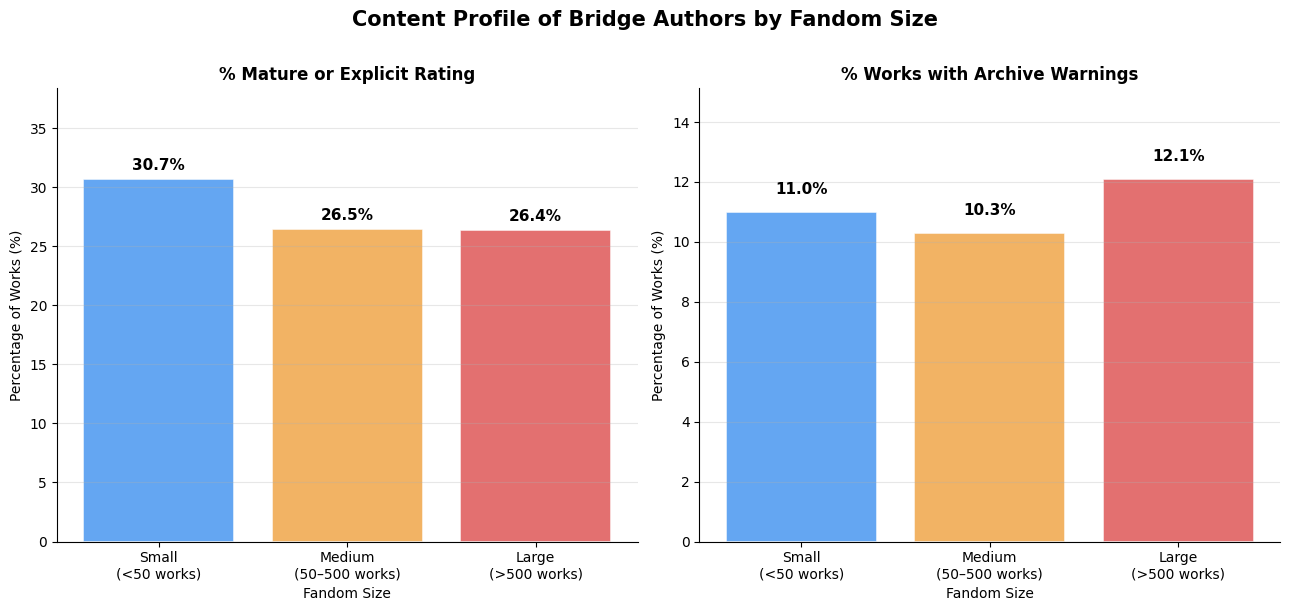

Saved: docs/fandom_size_content_profile_bridge.png

=== Percentile Summary — Bridge Authors ===
          Fandom Size   Metric    N  p10  p50  p90   p99
    Small (<50 works)     Hits 1847   35  409 2874 14719
    Small (<50 works)    Kudos 1847    3   26  180   815
    Small (<50 works) Comments 1847    2    5   23   139
Medium (50–500 works)     Hits 2934   74  591 4670 26064
Medium (50–500 works)    Kudos 2934    5   47  331  1737
Medium (50–500 works) Comments 2934    2    6   35   220
   Large (>500 works)     Hits 1176   62  538 3777 30689
   Large (>500 works)    Kudos 1176    4   38  273  1528
   Large (>500 works) Comments 1176    2    6   36   311


In [9]:
# ── 9. Bridge Author Analysis by Fandom Size ────────────────────────────

# ── Identify bridge authors (same logic as cell 10/earlier) ─────────────
# An author is a bridge if they have SEPARATE (non-crossover) works in
# at least 2 distinct fandoms.
single_fandom_works = manipulated_df[manipulated_df['count_fandom_tags'] == 1].copy()
single_fandom_works['author_str'] = single_fandom_works['parsed_authors'].apply(
    lambda x: x[0] if x else None)

author_fandom_sets = (
    single_fandom_works
    .dropna(subset=['author_str', 'fandom_tag_1'])
    .groupby('author_str')['fandom_tag_1']
    .apply(set)
)
bridge_authors = author_fandom_sets[author_fandom_sets.apply(len) >= 2].index
print(f'Bridge authors identified: {len(bridge_authors):,}')

# ── Build bridge-author work dataframe ──────────────────────────────────
bridge_df = manipulated_df[
    manipulated_df['parsed_authors'].apply(
        lambda x: x[0] if x else None).isin(bridge_authors)
].copy()

# Tag fandom size
bridge_df['fandom_size'] = bridge_df['fandom_tag_1'].map(fandom_counts).apply(
    fandom_size_label)

# ── Parse rating / archive warning columns ───────────────────────────────
from ao3_manipulator import AO3DataManipulator

if 'parsed_warnings' not in bridge_df.columns:
    bridge_df['parsed_warnings'] = bridge_df['Warning Tags'].apply(
        AO3DataManipulator.parse_list)
if 'archive_warning_binary' not in bridge_df.columns:
    bridge_df['archive_warning_binary'] = bridge_df['parsed_warnings'].apply(
        lambda x: 1 if (x != [' Creator Chose Not To Use Archive Warnings'] and
                        x != [' No Archive Warnings Apply']) else 0)

bridge_df['parsed_ratings'] = bridge_df['Rating Tags'].apply(
    AO3DataManipulator.parse_list)
bridge_df['is_mature_explicit'] = bridge_df['parsed_ratings'].apply(
    lambda x: 1 if any(r.strip() in ('Mature', 'Explicit') for r in x) else 0)

print(f'Bridge author works: {len(bridge_df):,}')
print(bridge_df['fandom_size'].value_counts())

# ── Plot A: Engagement distributions ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=False)
fig.suptitle('Engagement Distributions — Bridge Authors by Fandom Size',
             fontsize=16, fontweight='bold', y=1.01)

for ax, metric in zip(axes, metrics):
    plot_data = bridge_df[['fandom_size', metric]].dropna()
    plot_data = plot_data[plot_data[metric] > 0].copy()
    plot_data['log_metric'] = np.log10(plot_data[metric])

    sns.violinplot(data=plot_data, x='fandom_size', y='log_metric',
                   order=size_order, palette=size_palette,
                   inner=None, cut=0, alpha=0.55, ax=ax)
    sns.boxplot(data=plot_data, x='fandom_size', y='log_metric',
                order=size_order, palette=size_palette,
                width=0.15, fliersize=0, linewidth=1.5,
                boxprops=dict(alpha=0.9), ax=ax)

    for i, sz in enumerate(size_order):
        vals = plot_data.loc[plot_data['fandom_size'] == sz, metric]
        if len(vals) == 0:
            continue
        p50 = np.percentile(vals, 50)
        p90 = np.percentile(vals, 90)
        ax.text(i, np.log10(p50) + 0.05, f'p50: {int(p50):,}',
                ha='center', va='bottom', fontsize=7.5, color='#333')
        ax.text(i, np.log10(p90) + 0.05, f'p90: {int(p90):,}',
                ha='center', va='bottom', fontsize=7.5, color='#8B0000')

    ax.set_title(f'{metric} – Bridge Authors', fontsize=13, fontweight='semibold')
    ax.set_xlabel('')
    ax.set_ylabel(metric_labels[metric], fontsize=10)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f'{10**v:,.0f}'))
    ax.grid(axis='y', alpha=0.3)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('docs/fandom_size_distributions_bridge.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved: docs/fandom_size_distributions_bridge.png')

# ── Plot B: Mature/Explicit % and Archive Warning % ──────────────────────
content_rows = []
for sz in size_order:
    grp = bridge_df[bridge_df['fandom_size'] == sz]
    n = len(grp)
    pct_mature = 100 * grp['is_mature_explicit'].mean() if n else 0
    pct_warning = 100 * grp['archive_warning_binary'].mean() if n else 0
    content_rows.append({
        'Fandom Size': sz.replace('\n', ' '),
        'N works': n,
        '% Mature/Explicit': round(pct_mature, 1),
        '% With Archive Warning': round(pct_warning, 1),
    })
content_df = pd.DataFrame(content_rows)
print('\n=== Content Profile — Bridge Authors by Fandom Size ===')
print(content_df.to_string(index=False))

fig2, axes2 = plt.subplots(1, 2, figsize=(13, 6))
fig2.suptitle('Content Profile of Bridge Authors by Fandom Size',
              fontsize=15, fontweight='bold', y=1.01)

bar_palette = [size_palette[s] for s in size_order]
x_labels = [s.replace('\n', '\n') for s in size_order]

for ax2, col, title in zip(
        axes2,
        ['% Mature/Explicit', '% With Archive Warning'],
        ['% Mature or Explicit Rating', '% Works with Archive Warnings']):
    bars = ax2.bar(x_labels, content_df[col], color=bar_palette,
                   edgecolor='white', linewidth=1.2, alpha=0.88)
    for bar, val in zip(bars, content_df[col]):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=11, fontweight='semibold')
    ax2.set_ylim(0, max(content_df[col].max() * 1.25, 15))
    ax2.set_title(title, fontsize=12, fontweight='semibold')
    ax2.set_ylabel('Percentage of Works (%)', fontsize=10)
    ax2.set_xlabel('Fandom Size', fontsize=10)
    ax2.grid(axis='y', alpha=0.3)
    sns.despine(ax=ax2)

plt.tight_layout()
plt.savefig('docs/fandom_size_content_profile_bridge.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved: docs/fandom_size_content_profile_bridge.png')

# ── Combined summary table ────────────────────────────────────────────────
print('\n=== Percentile Summary — Bridge Authors ===')
rows2 = []
for sz in size_order:
    grp = bridge_df[bridge_df['fandom_size'] == sz]
    n = len(grp)
    for m in metrics:
        vals = grp[m].dropna()
        vals = vals[vals > 0]
        rows2.append({
            'Fandom Size': sz.replace('\n', ' '),
            'Metric': m,
            'N': n,
            'p10': int(np.percentile(vals, 10)) if len(vals) else None,
            'p50': int(np.percentile(vals, 50)) if len(vals) else None,
            'p90': int(np.percentile(vals, 90)) if len(vals) else None,
            'p99': int(np.percentile(vals, 99)) if len(vals) else None,
        })
summary_bridge = pd.DataFrame(rows2)
print(summary_bridge.to_string(index=False))


## 10. Inequality Within Fandoms: Gini Coefficient & p99/p50 Ratio

We measure **concentration of popularity within each fandom** on the Hits distribution across works:

- **Gini coefficient**: 0 = perfect equality (all works equally popular), 1 = maximum inequality (one work gets all hits).
- **p99/p50 ratio**: How many times more hits does a top-1% work receive vs. the median work in the same fandom? A ratio of 10× means blockbuster works far outpace the typical work; a ratio close to 1 means the fandom is relatively flat.

We scatter these per-fandom inequality scores against fandom size (log scale) to test whether larger fandoms exhibit stronger winner-takes-all dynamics.

Fandoms analyzed: 1,424

Top 10 by Gini (most unequal):
                                      fandom_tag_1  n_works  median_hits  gini_hits  p99_p50_hits
                                     Original Work      781         34.0   0.948916    756.052941
             Biohazard | Resident Evil (Gameverse)       70        527.5   0.911067    289.577118
Pocket Monsters | Pokemon (Main Video Game Series)       57        405.0   0.889526    220.328296
                      Harry Potter - J. K. Rowling     4137        644.0   0.880663    165.444658
                     Superman: The Animated Series       17          3.0   0.878204   1464.253333
                   Young Justice - All Media Types       16       2516.5   0.872667    148.848401
                                          DreamSMP       14        806.5   0.872483    142.236640
             Star Wars: The Book of Boba Fett (TV)       19        579.0   0.864728     99.610466
                          Black Widow (Movie 2021)       38   

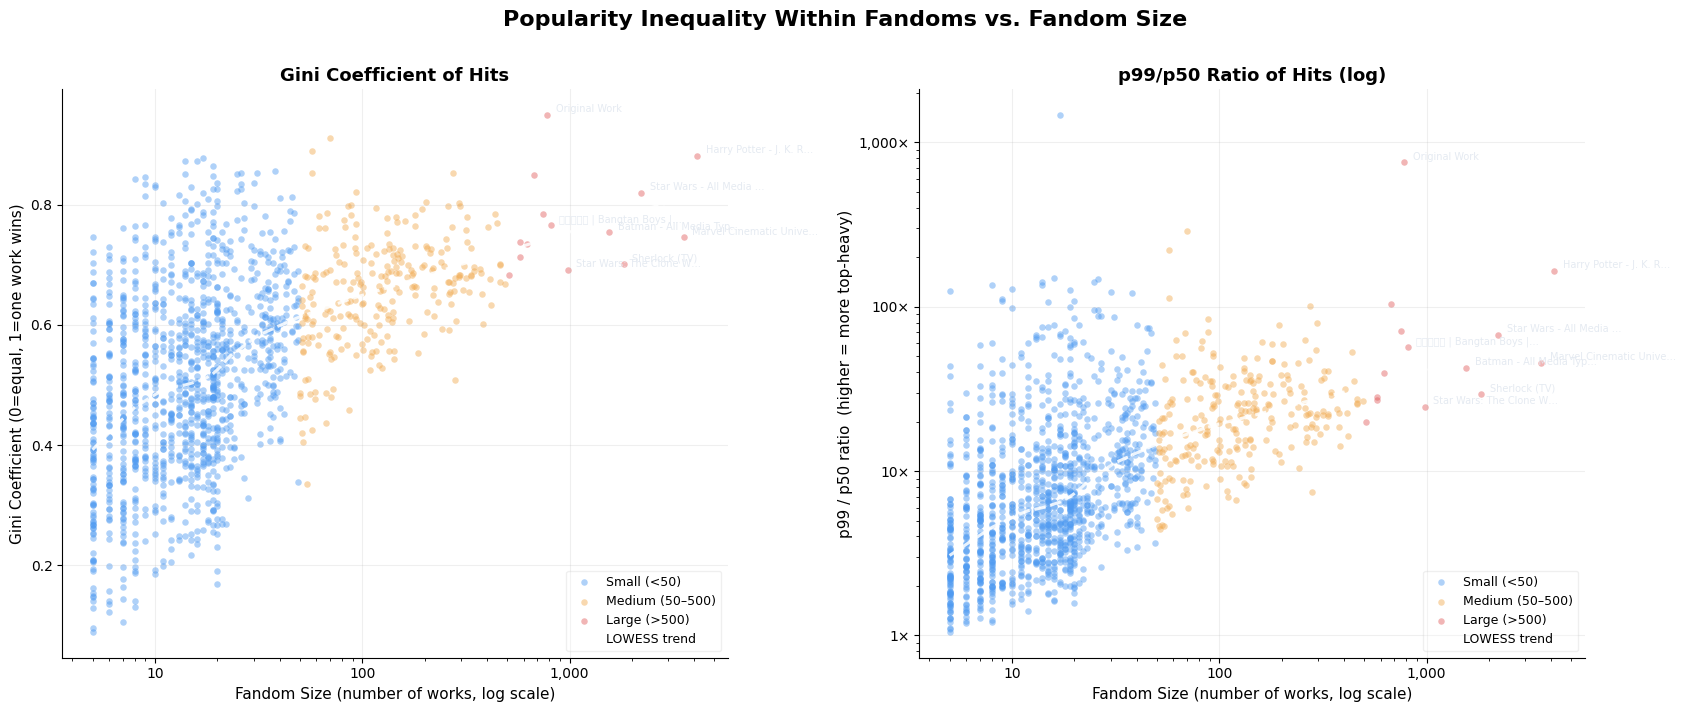

Saved: docs/inequality_vs_fandom_size.png


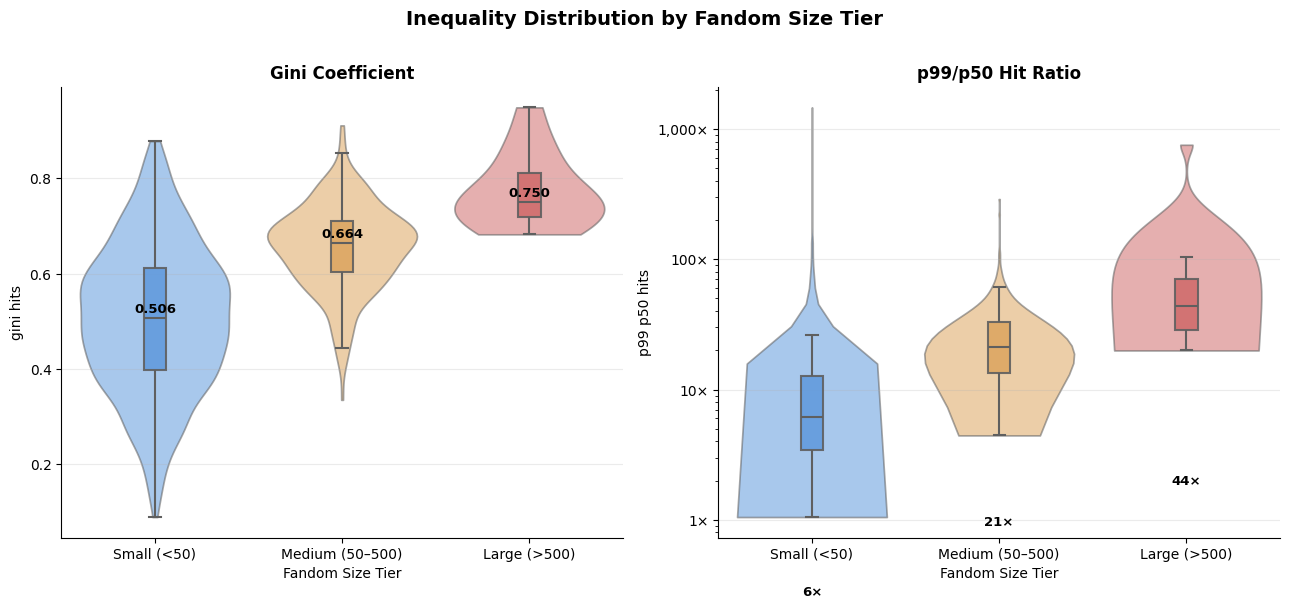

Saved: docs/inequality_by_tier.png

=== Inequality Summary by Tier ===
                gini_hits                                           p99_p50_hits                                                     
                    count  mean   std   min   25%   50%   75%   max        count    mean     std    min    25%    50%    75%      max
size_tier                                                                                                                            
Large (>500)         14.0  0.77  0.08  0.68  0.72  0.75  0.81  0.95         14.0  105.57  191.25  19.96  28.46  43.98  70.53   756.05
Medium (50–500)     254.0  0.65  0.09  0.34  0.60  0.66  0.71  0.91        254.0   26.61   26.43   4.45  13.50  21.33  32.71   289.58
Small (<50)        1156.0  0.51  0.15  0.09  0.40  0.51  0.61  0.88       1156.0   13.91   46.86   1.05   3.43   6.17  12.61  1464.25


In [10]:
# ── 10. Per-fandom Gini & p99/p50 ratio ────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.nonparametric.smoothers_lowess import lowess

# ── Gini helper ──────────────────────────────────────────────────────────
def gini(arr):
    arr = np.array(arr, dtype=float)
    arr = arr[arr > 0]
    if len(arr) < 2:
        return np.nan
    arr = np.sort(arr)
    n = len(arr)
    cumsum = np.cumsum(arr)
    return (2 * np.sum(np.arange(1, n + 1) * arr) / (n * cumsum[-1])) - (n + 1) / n

def p99_p50(arr):
    arr = np.array(arr, dtype=float)
    arr = arr[arr > 0]
    if len(arr) < 5:
        return np.nan
    p50 = np.percentile(arr, 50)
    if p50 == 0:
        return np.nan
    return np.percentile(arr, 99) / p50

# ── Compute per-fandom stats ──────────────────────────────────────────────
work_df = manipulated_df.copy()
work_df = work_df[work_df['Hits'] > 0].dropna(subset=['fandom_tag_1', 'Hits'])

fandom_stats = (
    work_df.groupby('fandom_tag_1')['Hits']
    .agg(
        n_works='count',
        total_hits='sum',
        median_hits='median',
        gini_hits=gini,
        p99_p50_hits=p99_p50
    )
    .reset_index()
)
fandom_stats = fandom_stats[fandom_stats['n_works'] >= 5].copy()

print(f'Fandoms analyzed: {len(fandom_stats):,}')
print(f'\nTop 10 by Gini (most unequal):')
print(fandom_stats.nlargest(10, 'gini_hits')
      [['fandom_tag_1','n_works','median_hits','gini_hits','p99_p50_hits']].to_string(index=False))
print(f'\nTop 10 by p99/p50:')
print(fandom_stats.nlargest(10, 'p99_p50_hits')
      [['fandom_tag_1','n_works','median_hits','gini_hits','p99_p50_hits']].to_string(index=False))
print(f'\nTop 10 by size (largest fandoms):')
print(fandom_stats.nlargest(10, 'n_works')
      [['fandom_tag_1','n_works','median_hits','gini_hits','p99_p50_hits']].to_string(index=False))

# ── Size tier ─────────────────────────────────────────────────────────────
def size_tier(n):
    if n < 50:   return 'Small (<50)'
    if n <= 500: return 'Medium (50–500)'
    return 'Large (>500)'

fandom_stats['size_tier'] = fandom_stats['n_works'].apply(size_tier)
tier_order  = ['Small (<50)', 'Medium (50–500)', 'Large (>500)']
tier_colors = {'Small (<50)': '#4E9AF1',
               'Medium (50–500)': '#F1A94E',
               'Large (>500)': '#E05C5C'}

# ── Spearman correlations ─────────────────────────────────────────────────
for metric, label in [('gini_hits', 'Gini'), ('p99_p50_hits', 'p99/p50')]:
    sub = fandom_stats[['n_works', metric]].dropna()
    r, p = stats.spearmanr(np.log10(sub['n_works']), sub[metric])
    print(f'{label} vs log(fandom size) → Spearman r={r:.3f}, p={p:.3e}')

# ── Plot A: Scatter — inequality vs fandom size ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('Popularity Inequality Within Fandoms vs. Fandom Size',
             fontsize=16, fontweight='bold', y=1.01)

plot_cfg = [
    ('gini_hits',    'Gini Coefficient (0=equal, 1=one work wins)', 'Gini Coefficient of Hits',    False),
    ('p99_p50_hits', 'p99 / p50 ratio  (higher = more top-heavy)',  'p99/p50 Ratio of Hits (log)', True),
]

for ax, (metric, ylabel, title, log_y) in zip(axes, plot_cfg):
    sub = fandom_stats.dropna(subset=[metric])

    for tier in tier_order:
        d = sub[sub['size_tier'] == tier]
        ax.scatter(d['n_works'], d[metric],
                   color=tier_colors[tier], label=tier,
                   alpha=0.45, s=22, linewidths=0)

    # LOWESS trend line
    xy = sub[['n_works', metric]].dropna().sort_values('n_works')
    y_vals = np.log10(xy[metric]) if log_y else xy[metric]
    smoothed = lowess(y_vals, np.log10(xy['n_works']), frac=0.4)
    y_trend = 10 ** smoothed[:, 1] if log_y else smoothed[:, 1]
    ax.plot(10 ** smoothed[:, 0], y_trend,
            color='white', linewidth=2.2, alpha=0.85,
            linestyle='--', label='LOWESS trend')

    # Annotate largest fandoms
    for _, row in sub.nlargest(8, 'n_works').iterrows():
        name = row['fandom_tag_1']
        short = name[:22] + ('…' if len(name) > 22 else '')
        ax.annotate(short,
                    xy=(row['n_works'], row[metric]),
                    xytext=(6, 2), textcoords='offset points',
                    fontsize=7, color='#e2e8f0', alpha=0.9)

    ax.set_xscale('log')
    if log_y:
        ax.set_yscale('log')
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda v, _: f'{v:,.0f}×'))
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
    ax.set_xlabel('Fandom Size (number of works, log scale)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='semibold')
    ax.legend(fontsize=9, framealpha=0.3)
    ax.grid(alpha=0.2)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('docs/inequality_vs_fandom_size.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: docs/inequality_vs_fandom_size.png')

# ── Plot B: Violin+box by tier ────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 6))
fig2.suptitle('Inequality Distribution by Fandom Size Tier',
              fontsize=14, fontweight='bold', y=1.01)

for ax2, metric, title2, log_y in [
        (axes2[0], 'gini_hits',    'Gini Coefficient',   False),
        (axes2[1], 'p99_p50_hits', 'p99/p50 Hit Ratio',  True)]:

    plot_data = fandom_stats.dropna(subset=[metric])
    y_col = metric

    sns.violinplot(data=plot_data, x='size_tier', y=y_col,
                   order=tier_order, palette=tier_colors,
                   inner=None, cut=0, alpha=0.55, ax=ax2)
    sns.boxplot(data=plot_data, x='size_tier', y=y_col,
                order=tier_order, palette=tier_colors,
                width=0.12, fliersize=0, linewidth=1.5,
                boxprops=dict(alpha=0.9), ax=ax2)

    for i, tier in enumerate(tier_order):
        vals = plot_data.loc[plot_data['size_tier'] == tier, metric].dropna()
        med  = vals.median()
        label = f'{med:.3f}' if not log_y else f'{med:.0f}×'
        offset = med * 0.04 if log_y else med + 0.005
        ax2.text(i, offset, label,
                 ha='center', va='bottom', fontsize=9.5, fontweight='bold')

    if log_y:
        ax2.set_yscale('log')
        ax2.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda v, _: f'{v:,.0f}×'))

    ax2.set_title(title2, fontsize=12, fontweight='semibold')
    ax2.set_xlabel('Fandom Size Tier', fontsize=10)
    ax2.set_ylabel(metric.replace('_', ' '), fontsize=10)
    ax2.grid(axis='y', alpha=0.25)
    sns.despine(ax=ax2)

plt.tight_layout()
plt.savefig('docs/inequality_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: docs/inequality_by_tier.png')

# ── Summary stats table ───────────────────────────────────────────────────
summary = fandom_stats.groupby('size_tier')[['gini_hits','p99_p50_hits']].describe(
    percentiles=[.25, .5, .75]).round(2)
print('\n=== Inequality Summary by Tier ===')
print(summary.to_string())
